In [ ]:
# Import packages
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import simpeg to re-construct mesh
from discretize import TensorMesh

# Import sklearn for normalization
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Import pytorch and sklearn for ML
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split


In [2]:
# Set directives
plt.rcParams['figure.figsize'] = [16, 12]
plt.rcParams['image.cmap'] = 'cividis'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['figure.dpi'] = 72
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.labelpad'] = 5
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['text.usetex'] = False

%matplotlib inline
%config InlineBackend.figure_format = 'retina'    # Hi-res plots

 # Press warning
warnings.filterwarnings("ignore")   


# Config machine

In [4]:
# Set device for training
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Not using CUDA")


Using device: mps
Not using CUDA


# Load Data Sets

In [5]:
# Re-construct mesh

# Set dimension of model space
n_core_x, n_core_y, n_core_z = 45, 20, 45   # Setting number of core cells
core_hx, core_hy, core_hz = 4000/n_core_x, 2000/n_core_y, 4000/n_core_z    # Setting size of core cells 
npadx, npady, npadz = 8, 8, 8    # Setting number of padding cells
padding_factor = 1.5

# Generate 3D mesh with user input
mesh_3d = TensorMesh([
    [(core_hx, npadx, -padding_factor), (core_hx, n_core_x), (core_hx, npadx, padding_factor)],
    [(core_hy, npady-2, -padding_factor), (core_hy, n_core_y), (core_hy, npady, padding_factor)],
    [(core_hz, npadz-3, -padding_factor), (core_hz, n_core_z), (core_hz, npadz, padding_factor)]
    ]) 

# Set the center of meshed space
mesh_3d.x0 = np.r_[
    -(mesh_3d.h[0][:npadx].sum()*1.1),
    -(mesh_3d.h[1][:npady + n_core_y-6].sum()),
    -(mesh_3d.h[2][:npadz-3 + n_core_z].sum())
]

# Get total number of cells (core and padding) in x, y, z direction
Nx, Ny, Nz = mesh_3d.shape_cells


In [8]:
# Load hyper-parameters
Hyper_Param_raw = np.load('../Prior falsification/Generated prior/' + 'Hyper_Param.npy')

# Load saved conductivity model and EM data files
EMsigma_core_raw_1d = np.load('../Prior falsification/Generated prior/' + 'EMsigma_core.npy')
dpred_raw = np.load('../Prior falsification/Generated prior/' + "dpred.npy")
dpred_clean = dpred_raw[:, :, :].copy()

# Reorganize conductivity model to restall its 2D shape
EMsigma_core_raw = np.zeros((EMsigma_core_raw_1d.shape[0], n_core_x, n_core_y, n_core_z))
for i in range(EMsigma_core_raw_1d.shape[0]):
    EMsigma_core_raw[i, :, :] = EMsigma_core_raw_1d[i, :].reshape((n_core_x, n_core_y, n_core_z), order='F')

# Reorganize EM data to have shape of [channel * loc]
dpred_clean = dpred_clean.transpose(0, 2, 1)

# Get key dimensions
N_model = dpred_clean.shape[0]
N_times =  dpred_clean.shape[1]
N_obs = dpred_clean.shape[2]



In [9]:
# Load receiver locations
Rx_loc = pd.read_csv("../Prior falsification/Test data/" + 'Rx_loc.csv', header=None).to_numpy()
Nrx = Rx_loc.shape[0]


In [10]:
# Data augmentation
N_augment = 3
dpred_augment = []
for k in range(N_augment):
    dpred_noise = dpred_clean.copy()
    for i in range(N_model):
        percentage = np.random.uniform(low=0, high=0.05)
        for j in range(N_times):
            Std = np.mean(np.abs(dpred_clean[i, j, :])) * percentage
            dpred_noise[i, j, :] += np.random.normal(loc=0, scale=Std, size=N_obs)
    dpred_augment.append(dpred_noise)

# Combine clean and noisy data
dpred = np.vstack([dpred_clean, *dpred_augment])

# Duplicate model so noisy data has corresponding conductivity model
EMsigma_core = np.vstack([EMsigma_core_raw] * (N_augment + 1))
hyper_param = np.vstack([Hyper_Param_raw] * (N_augment + 1))


# Prepare Training, Validation, and Test Sets

In [11]:
# Get ratio of training, validation, and testing sets in the whole data set
train_persent = 0.8
val_persent = 0.15
test_persent = 0.05

# Split CLEAN data first
N_original_set = EMsigma_core_raw.shape[0]    # Number of original noise-free samples
np.random.seed(42)
original_indices = np.arange(N_original_set)
np.random.shuffle(original_indices)

N_test  = int(test_persent  * N_original_set)
N_val   = int(val_persent   * N_original_set)
N_train = N_original_set - N_test - N_val

test_indices  = original_indices[:N_test]
val_indices   = original_indices[N_test:N_test + N_val]
train_indices = original_indices[N_test + N_val:]

print(f"Clean split  →  train: {N_train}  val: {N_val}  test: {N_test}")

Clean split  →  train: 800  val: 150  test: 50


In [12]:
# Augment ONLY the training split 
dpred_train_clean = dpred_clean[train_indices]
sigma_train_clean = EMsigma_core_raw[train_indices]  

N_augment=7
augmented_dpred = [dpred_train_clean]
augmented_sigma = [sigma_train_clean]
for _ in range(N_augment):
    dpred_noise = dpred_train_clean.copy()
    for i in range(N_train):
        percentage = np.random.uniform(low=0.0, high=0.1)
        for j in range(N_times):
            std = np.mean(np.abs(dpred_train_clean[i, j, :])) * percentage
            dpred_noise[i, j, :] += np.random.normal(0, std, size=N_obs)
    augmented_dpred.append(dpred_noise)
    augmented_sigma.append(sigma_train_clean)   # same labels for every copy

#  Combine clean train + augmented train
dpred_train = np.vstack(augmented_dpred)
EMsigma_train = np.vstack(augmented_sigma)

print(f"After augmentation, train samples: {len(dpred_train)}")


After augmentation, train samples: 6400


In [13]:
# Make validation and testing sets
dpred_val  = dpred_clean[val_indices]
EMsigma_val  = EMsigma_core_raw[val_indices]

dpred_test = dpred_clean[test_indices]
EMsigma_test = EMsigma_core_raw[test_indices]

In [14]:
# Transfer data to PyTorch tensors and create Dataset objects for training, validation, and testing
# Convert inputs from np.array to tensor
EMsigma_train_tensor = torch.from_numpy(EMsigma_train).unsqueeze(1).to(torch.float32)  # (N,1,45,20,45)
EMsigma_train_tensor = torch.from_numpy(EMsigma_train).unsqueeze(1).to(torch.float32)  # (N,1,45,20,45)
EMsigma_val_tensor = torch.from_numpy(EMsigma_val).unsqueeze(1).to(torch.float32)
EMsigma_test_tensor = torch.from_numpy(EMsigma_test).unsqueeze(1).to(torch.float32)

# Convert targets from np.array to tensor
dpred_train_tensor = torch.from_numpy(dpred_train).to(torch.float32)  # (N,12,19)
dpred_val_tensor = torch.from_numpy(dpred_val).to(torch.float32)
dpred_test_tensor = torch.from_numpy(dpred_test).to(torch.float32)

# Pack input and output
train_set = TensorDataset(EMsigma_train_tensor, dpred_train_tensor)
val_set = TensorDataset(EMsigma_val_tensor, dpred_val_tensor)
test_set = TensorDataset(EMsigma_test_tensor, dpred_test_tensor)

batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=len(test_indices), shuffle=False, pin_memory=True)


# Set and Train Surrogate Model

In [11]:
# Define NN

# Building blocks
class ConvBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.2, norm="instance"):
        super().__init__()
        Norm = nn.InstanceNorm3d if norm == "instance" else nn.BatchNorm3d
        self.net = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            Norm(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout3d(dropout_p) if dropout_p > 0 else nn.Identity(),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            Norm(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout3d(dropout_p) if dropout_p > 0 else nn.Identity(),
        )

    def forward(self, x):
        return self.net(x)

class Downsample3D(nn.Module):
    """Learnable downsample: halves D,H,W via stride-2 conv (MPS-friendly)."""
    def __init__(self, in_ch, out_ch, norm="instance"):
        super().__init__()
        Norm = nn.InstanceNorm3d if norm == "instance" else nn.BatchNorm3d
        self.conv = nn.Conv3d(in_ch, out_ch, kernel_size=3, stride=2, padding=1)
        self.bn   = Norm(out_ch)
        self.act  = nn.ReLU(inplace=True)
        
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

def _interp1d_along(x, out_len: int, dim: int):
    """
    Upsample along a single spatial dim using 1D linear interpolate (MPS-safe).
    x: (B, C, D, H, W)
    dim: 2 (D) or 3 (H) or 4 (W)
    """
    assert dim in (2, 3, 4)
    B, C, D, H, W = x.shape
    if dim == 2:
        x = x.permute(0,1,3,4,2).contiguous().view(B*C*H*W, 1, D)  # (BCHW,1,D)
        x = F.interpolate(x, size=out_len, mode="linear", align_corners=False)
        x = x.view(B, C, H, W, out_len).permute(0,1,4,2,3).contiguous()
    elif dim == 3:
        x = x.permute(0,1,2,4,3).contiguous().view(B*C*D*W, 1, H)  # (BCD*W,1,H)
        x = F.interpolate(x, size=out_len, mode="linear", align_corners=False)
        x = x.view(B, C, D, W, out_len).permute(0,1,2,4,3).contiguous()
    else:  # dim == 4
        x = x.view(B*C*D*H, 1, W)                                  # (BCD*H,1,W)
        x = F.interpolate(x, size=out_len, mode="linear", align_corners=False)
        x = x.view(B, C, D, H, out_len)
    return x

class UpSample3D_Separable(nn.Module):
    """
    MPS-safe upsampling: do 1D linear interpolate along D, then H, then W,
    then a 1x1x1 conv to set channels.
    """
    def __init__(self, in_ch, out_ch, norm="instance"):
        super().__init__()
        Norm = nn.InstanceNorm3d if norm == "instance" else nn.BatchNorm3d
        self.proj = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=1, bias=False),
            Norm(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, target_size):
        # target_size is a tuple (D_t, H_t, W_t)
        Dt, Ht, Wt = target_size
        if x.shape[2] != Dt:
            x = _interp1d_along(x, Dt, dim=2)
        if x.shape[3] != Ht:
            x = _interp1d_along(x, Ht, dim=3)
        if x.shape[4] != Wt:
            x = _interp1d_along(x, Wt, dim=4)
        return self.proj(x)


def sample_along_x_linear(y_1d: torch.Tensor, x_coords_norm, N_x: int) -> torch.Tensor:
    """
    y_1d: (B, C, Dx)  — features along x after (y,z) squeeze
    x_coords_norm: (N_x,) or (B,N_x), numpy or torch, normalized to [-1,1]
    returns: (B, C, N_x)
    """
    B, C, Dx = y_1d.shape

    # accept numpy or torch, move/cast to match y_1d
    if isinstance(x_coords_norm, np.ndarray):
        x_coords = torch.as_tensor(x_coords_norm, device=y_1d.device, dtype=y_1d.dtype)
    elif not torch.is_tensor(x_coords_norm):
        x_coords = torch.tensor(x_coords_norm, device=y_1d.device, dtype=y_1d.dtype)
    else:
        x_coords = x_coords_norm.to(device=y_1d.device, dtype=y_1d.dtype)

    # normalize [-1,1] -> index space [0, Dx-1]
    x_idx = 0.5 * (x_coords + 1) * (Dx - 1)   # (N_x,) or (B,N_x)

    # floor/ceil and weights
    i0 = torch.floor(x_idx).clamp(0, Dx - 1)
    i1 = (i0 + 1).clamp(0, Dx - 1)
    w1 = (x_idx - i0).clamp(0, 1)
    w0 = 1 - w1

    # shape to (B,1,N_x)
    if x_idx.dim() == 1:
        i0 = i0[None, :].expand(B, -1)
        i1 = i1[None, :].expand(B, -1)
        w0 = w0[None, :].expand(B, -1)
        w1 = w1[None, :].expand(B, -1)

    # long indices for gather
    i0_long = i0.long()  # (B,N_x)
    i1_long = i1.long()

    # gather expects index shape (B,C,N_x)
    i0_g = i0_long[:, None, :].expand(B, C, -1)
    i1_g = i1_long[:, None, :].expand(B, C, -1)

    # (B,C,N_x) from (B,C,Dx)
    y0 = torch.gather(y_1d, dim=2, index=i0_g)
    y1 = torch.gather(y_1d, dim=2, index=i1_g)

    # blend
    w0 = w0[:, None, :]  # (B,1,N_x)
    w1 = w1[:, None, :]
    y_lin = w0 * y0 + w1 * y1  # (B,C,N_x)
    return y_lin


def center_crop_to(x, ref):
    """Center-crop x spatial dims (D,H,W) to ref's."""
    _, _, D, H, W = x.shape
    _, _, Dr, Hr, Wr = ref.shape
    d0 = max((D - Dr) // 2, 0)
    h0 = max((H - Hr) // 2, 0)
    w0 = max((W - Wr) // 2, 0)
    return x[:, :, d0:d0+Dr, h0:h0+Hr, w0:w0+Wr]

    

# ------------ Main model (no pooling ops) ------------
class UNet3D_Profile(nn.Module):
    """
    Input:  (B, 1, 45, 20, 45)  ln-conductivity
    Output: (B, n_times, 19)    (12 time channels, 19 x-positions)

    No MaxPool/AvgPool anywhere (uses strided Conv3d); x→19 via 1D interpolate.
    """
    def __init__(
        self,
        in_channels=1,
        n_times=12,
        base_ch=32,
        depth=4,
        dropout_p=0.25,
        norm="instance",
        learn_mix=False,      # False = depthwise (per-channel) squeeze over (y,z)
        use_grid_x=False,     # False = x resample by interpolate to 19; True = grid_sample (optional)
        N_x=19,
    ):
        super().__init__()
        self.depth = depth
        self.n_times = n_times
        self.learn_mix = learn_mix
        self.use_grid_x = use_grid_x
        self.N_x = N_x

        # Encoder stages and learnable downsamples
        chans = [base_ch * (2 ** i) for i in range(depth)]  # e.g., [32, 64, 128, 256]
        self.enc = nn.ModuleList()
        self.down = nn.ModuleList()

        # enc[0]: 1 -> chans[0]
        self.enc.append(ConvBlock3D(in_channels, chans[0], dropout_p=dropout_p, norm=norm))

        # enc[1..]: chans[i] -> chans[i]
        for i in range(1, depth):
            self.enc.append(ConvBlock3D(chans[i], chans[i], dropout_p=dropout_p, norm=norm))
        
        # down[i]: chans[i] -> chans[i+1]  for i = 0 .. depth-2
        for i in range(depth - 1):
            self.down.append(Downsample3D(chans[i], chans[i+1], norm=norm))

        # Bottleneck
        self.bottleneck = ConvBlock3D(chans[-1], chans[-1] * 2, dropout_p=dropout_p, norm=norm)

        # Decoder (transpose-conv upsampling)
        self.up = nn.ModuleList()
        self.dec = nn.ModuleList()
        ch = chans[-1] * 2
        for c in reversed(chans):
            self.up.append(UpSample3D_Separable(ch, c, norm=norm))       
            self.dec.append(ConvBlock3D(c * 2, c, dropout_p=dropout_p, norm=norm))
            ch = c

        # Harmonize channel count at the end of decoder
        self.final_feat = nn.Conv3d(chans[0], chans[0], kernel_size=1)

        # Learned squeeze over (y,z); initialize lazily to match Hy,Wz
        #self.squeeze_yz = None  # Conv3d(C->C, kernel=(1,Hy,Wz), groups=C or 1)
        C = chans[0]                                # channels right before squeeze
        groups = 1 if self.learn_mix else C
        self.squeeze_yz = nn.Conv3d(
            in_channels=C, out_channels=C,
            kernel_size=(1, 20, 45),  # H=20, W=45
            stride=1, padding=0, bias=True, groups=groups
        )

        # Head to map features → n_times along x
        self.time_head = nn.Sequential(
            nn.Conv1d(chans[0], chans[0], kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p) if dropout_p > 0 else nn.Identity(),
            nn.Conv1d(chans[0], n_times, kernel_size=1),
        )

    def forward(self, x, x_coords_norm=None):
        # x: (B, 1, 45, 20, 45)
        B = x.size(0)

        # ----- Encoder -----
        skips = []
        y = x
        for i in range(self.depth):
            y = self.enc[i](y)          # (B, chans[i], ...)
            skips.append(y)
            if i < self.depth - 1:
                y = self.down[i](y)     # (B, chans[i+1], ...)...)

        # ----- Bottleneck -----
        y = self.bottleneck(y)

        # ----- Decoder -----
        for i in range(self.depth):
            skip = skips[-(i + 1)]
            y = self.up[i](y, target_size=skip.shape[2:])   # MPS-safe upsample
            y = torch.cat([y, skip], dim=1)
            y = self.dec[i](y)

        # Bring back to the exact input spatial size (45,20,45)
        y = self.final_feat(y)
        Dt, Ht, Wt = x.shape[2:]
        if y.shape[2] != Dt:
            y = _interp1d_along(y, Dt, dim=2)
        if y.shape[3] != Ht:
            y = _interp1d_along(y, Ht, dim=3)
        if y.shape[4] != Wt:
            y = _interp1d_along(y, Wt, dim=4)

        # ----- Learned squeeze over (y,z) → (B, C, 45, 1, 1) -----
        _, C, Dx, Hy, Wz = y.shape
        if (self.squeeze_yz is None or
            self.squeeze_yz.in_channels != C or
            self.squeeze_yz.out_channels != C or
            self.squeeze_yz.weight.shape[2:] != (1, Hy, Wz)):
            groups = 1 if self.learn_mix else C  # groups=C = depthwise per-channel squeeze
            self.squeeze_yz = nn.Conv3d(
                in_channels=C, out_channels=C,
                kernel_size=(1, Hy, Wz), stride=1, padding=0,
                bias=True, groups=groups
            ).to(y.device)
        y = self.squeeze_yz(y)                   # (B, C, Dx, 1, 1)
        y = y.squeeze(-1).squeeze(-1)            # (B, C, Dx)

        # ----- Choose 19 x-positions -----
        if self.use_grid_x:
            # Optional path (irregular stations). Uses grid_sample on a (B,C,Dx,1,1) tensor.
            # grid_sample(3D) is usually OK on MPS, but if you ever hit an op gap,
            # prefer the interpolate path below + custom 1D linear gather.
            if x_coords_norm is None:
                raise ValueError("use_grid_x=True requires x_coords_norm in [-1,1] of shape (N_x,) or (B,N_x).")
            y3 = y.unsqueeze(-1).unsqueeze(-1)  # (B, C, Dx, 1, 1)
            if x_coords_norm.dim() == 1:
                xg = x_coords_norm.view(1, self.N_x, 1, 1).expand(B, -1, -1, -1)
            else:
                xg = x_coords_norm.view(B, self.N_x, 1, 1)
            yg = torch.zeros_like(xg)
            zg = torch.zeros_like(xg)
            grid = torch.stack((xg, yg, zg), dim=-1)  # (B, N_x, 1, 1, 3)
            y = sample_along_x_linear(y, x_coords_norm, self.N_x)  # -> (B,C,19)
        else:
            # MPS-safe: 1D interpolate to exactly 19 samples along x
            y = F.interpolate(y, size=self.N_x, mode="linear", align_corners=False)  # (B, C, 19)

        # ----- Map features → time channels -----
        out = self.time_head(y)  # (B, n_times, 19)
        return out



# Define function for parameter initialization
def init_weights(m):
    if isinstance(m, nn.Conv3d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)


In [ ]:
# Define the customized loss function
class CustomLoss(nn.Module):
    def __init__(self):
        super(CustomLoss, self).__init__()
        self.MSE_loss = nn.MSELoss()
       
    def forward(self, outputs, targets):
        
        # Weight MSE loss by 1/dynamic range (DR) of each channel
        channel_max = torch.max(targets, dim=2)[0]
        channel_min = torch.min(targets, dim=2)[0]
        dynamic_range = (channel_max - channel_min).clamp_min(1e-12)
        weights = 1.0 / (dynamic_range) ** 2    # Construct weights for rach channel based on dynamic range of true data
        weights = weights.view(outputs.shape[0], outputs.shape[1], 1)
        
        diff = (outputs - targets) ** 2 # Calculate weighted MSE
        DR_weightex_loss = torch.mean(diff * weights)
        Loss = DR_weightex_loss
        
        return Loss
        

In [ ]:
# Define training function
def train(model, criterion, optimizer,
          train_loader, val_loader, 
          device,
          lr_scheduler,
          max_epochs=100,
          val_interval=5, 
          early_stopping_patience=10,
          x_coords_norm=None):
    """
    Function to train a:d validate NN.
    Input: model: Neural network model.
           criterion: Loss function.
           optimizer: Optimizer to update NN parameter in training
           train_loader: Data loader for training set, dataloader.
           val_dataset: Whole validation set, tensor.
           device: cpu or gpu device, torch.device.
           lr_scheduler: Learning rate scheduler.
           max_epochs: Maximum number of training epochs, default is 100, int.
           val_interval: Interval epochs between each validation. defualt is 5, 
                         means validate every 5 epoch, int.
           early_stopping_patience: How many times tolerating non-decreasing validation loss
    """
            
    # Pring the number of parameter in the NN
    num_params = 0
    for param in model.parameters():
        num_params += param.nelement()
    print(f"# of params in NN model: {num_params}\n")

    # Initialize train loss recorder
    MSE_loss_record = []    # BCE training loss

    # Initialize validation loss recorder
    val_epoch_record = []    # record epoch number, for plotting
    val_loss_record = []    # Record validation loss

    # Initialize learning rate recorder
    lr_record = []
 
    # Initialize earily-stopping parameters
    no_improve_epochs = 0  # Counter for epochs without improvement
    best_avg_val_loss = float('inf')  # Set initial best loss to infinity
   
    # Initialize check-point parameters
    best_val_loss = float('inf')
    best_model_state = None  # to store the best model state

    # Train and validation
    epoch = 0
    for epoch in range(max_epochs):

        # Initialize loss in each epoch
        MSE_loss = 0
        
        # Training phase
        model.train()    # Set NN to training mode
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)    # Send inputs and label to gpu or cpu

            # Forward pass
            optimizer.zero_grad()    # Clear gradient for this training 
            outputs = model(inputs, x_coords_norm=x_coords_norm)   # Forward pass to get prediction
            train_loss_iter = criterion(outputs, targets)    # Calculate loss
                
            train_loss_iter.backward()    # Back propogate loss
            optimizer.step()    # Update parameters

            # Record different losses separately
            MSE_loss += train_loss_iter.item()

        # Record average losses for each epoch
        MSE_loss_record.append(MSE_loss / len(train_loader))

        # Print total loss after each epoch
        print(f'Epoch [{epoch+1}], Training Loss: {MSE_loss_record[-1]:.4f}')

        current_lr = optimizer.param_groups[0]['lr']
        lr_record.append(current_lr)

        # Validate every 5 epochs
        if (epoch + 1) % val_interval == 0:
            val_epoch_record.append(epoch+1)

            # Validation phase
            model.eval()    # Set NN to evaliation mode
            val_loss = 0
            with torch.inference_mode():
                for inputs, targets in val_loader:
                    inputs, targets = inputs.to(device), targets.to(device)

                    # Forward pass and get loss
                    outputs = model(inputs, x_coords_norm=x_coords_norm)
                    val_loss_iter = criterion(outputs, targets)
                    val_loss += val_loss_iter.item()
            
            # Clalculate validation results
            val_loss_record.append(val_loss / len(val_loader))

            # Print validation loss and accuracy
            print(f"\nVal loss: {val_loss_record[-1]:.4f}")

            # Check-point, save the best model state
            if val_loss_record[-1] <= best_val_loss:
                best_val_loss = val_loss_record[-1]
                best_model_state = copy.deepcopy(model.state_dict())    # Deep copy best model state
                best_val_which_epoch = epoch

            # Early stopping
            # Calculate average of the last 3 validation losses
            if len(val_loss_record) >= 3:
                avg_val_loss = np.mean(np.array(val_loss_record)[-3:])
                # Check if the new average is better (i.e., lower) than the best average so far
                if avg_val_loss < best_avg_val_loss:
                    best_avg_val_loss = avg_val_loss
                    no_improve_epochs = 0  # Reset counter if there's an improvement
                else:
                    no_improve_epochs += 1  # Increment counter if no improvement
    
            # Check if we have not improved for a number of epochs equal to the patience
            if no_improve_epochs >= early_stopping_patience:
                print(f"Early stopping triggered after epoch {epoch+1}")
                print(f"Best valid loss is {best_val_loss:.4f} at epoch {best_val_which_epoch}")

                break  # Stop training

            # Set NN back to training mode
            model.train()    
    
            # Step the scheduler after each epoch
            lr_scheduler.step(val_loss_record[-1])

        # Update epoch counter
        epoch += 1

    # After training is complete or early stopping is triggered
    # Restore the best model state
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return {
        "epochs": epoch,
        "State": best_model_state,
        "MSE_train_loss": MSE_loss_record,
        "val_epoch_record": val_epoch_record,
        "val_loss_record": val_loss_record,
        "lr_record": lr_record
        }


In [ ]:
## Run training 
if __name__ == "__main__":
    # Setting configuration
    CONFIG = {
        "input_channels": 1,    # Input channel number
        "output_channels": 12,    # Output channel number
        "max_epochs": 1000,   # Maximum number of epochs
        "learning_rate": 1e-3,    # Initial learning rate
        "val_interval": 5,    # Epoch interval between each validation
        "early_stopping_patience": 10
        }

    # Convert Rx locs
    scaler = MinMaxScaler(feature_range=(-1, 1))
    x_coords = scaler.fit_transform(Rx_loc[:, 0].reshape(-1, 1)).ravel()
    x_coords = np.asarray(x_coords, dtype=np.float32)        # or whatever you have
    x_coords = torch.as_tensor(
        x_coords, device=device
    )

    # Define NN
    model = UNet3D_Profile(
        in_channels=1,
        n_times=CONFIG["output_channels"], 
        base_ch=32, 
        depth=3,
        dropout_p=0.2, 
        norm="instance",
        learn_mix=False,
        use_grid_x=True,  # enables grid_sample
        N_x=19
    )
    model.to(device)

    # Set loss-criterion and optimizer
    criterion = CustomLoss()
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=CONFIG["learning_rate"],
        weight_decay=1e-2
    )
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', 
        factor=0.5, patience=5
    )    # Reduce learning rate if loss plateaus

    # Initialize model weights if the file does not exist
    init_weights(model)
    
    # Start training.
    Train_results = train(
        model, criterion, optimizer,
        train_loader, 
        val_loader,
        device, 
        lr_scheduler,
        CONFIG["max_epochs"], 
        CONFIG["val_interval"],
        CONFIG["early_stopping_patience"],
        x_coords_norm=x_coords
        )

    # Extract parameters
    model_state = Train_results["State"]

    # Extract number of epoches, losses, and accuracy for plotting
    total_epochs = Train_results["epochs"]
    MSE_loss = Train_results["MSE_train_loss"]
    val_epochs = Train_results["val_epoch_record"]
    val_loss = Train_results["val_loss_record"]
    lr_history = Train_results["lr_record"]
    

# of params in NN model: 5882892

Epoch [1], Training Loss: 1179.5247
Epoch [2], Training Loss: 470.9353
Epoch [3], Training Loss: 350.4357
Epoch [4], Training Loss: 308.4246
Epoch [5], Training Loss: 278.4710

Val loss: 242.5281
Epoch [6], Training Loss: 255.4578
Epoch [7], Training Loss: 230.1231
Epoch [8], Training Loss: 201.9832
Epoch [9], Training Loss: 182.5426
Epoch [10], Training Loss: 173.9580

Val loss: 129.2152
Epoch [11], Training Loss: 163.7372
Epoch [12], Training Loss: 148.9532
Epoch [13], Training Loss: 143.7780
Epoch [14], Training Loss: 138.1085
Epoch [15], Training Loss: 120.7529

Val loss: 78.6578
Epoch [16], Training Loss: 120.6766
Epoch [17], Training Loss: 112.9186
Epoch [18], Training Loss: 112.3301
Epoch [19], Training Loss: 108.6728
Epoch [20], Training Loss: 104.3345

Val loss: 74.3575
Epoch [21], Training Loss: 101.1961
Epoch [22], Training Loss: 100.4693
Epoch [23], Training Loss: 97.1247
Epoch [24], Training Loss: 91.9427
Epoch [25], Training Loss: 94.2892

# Test

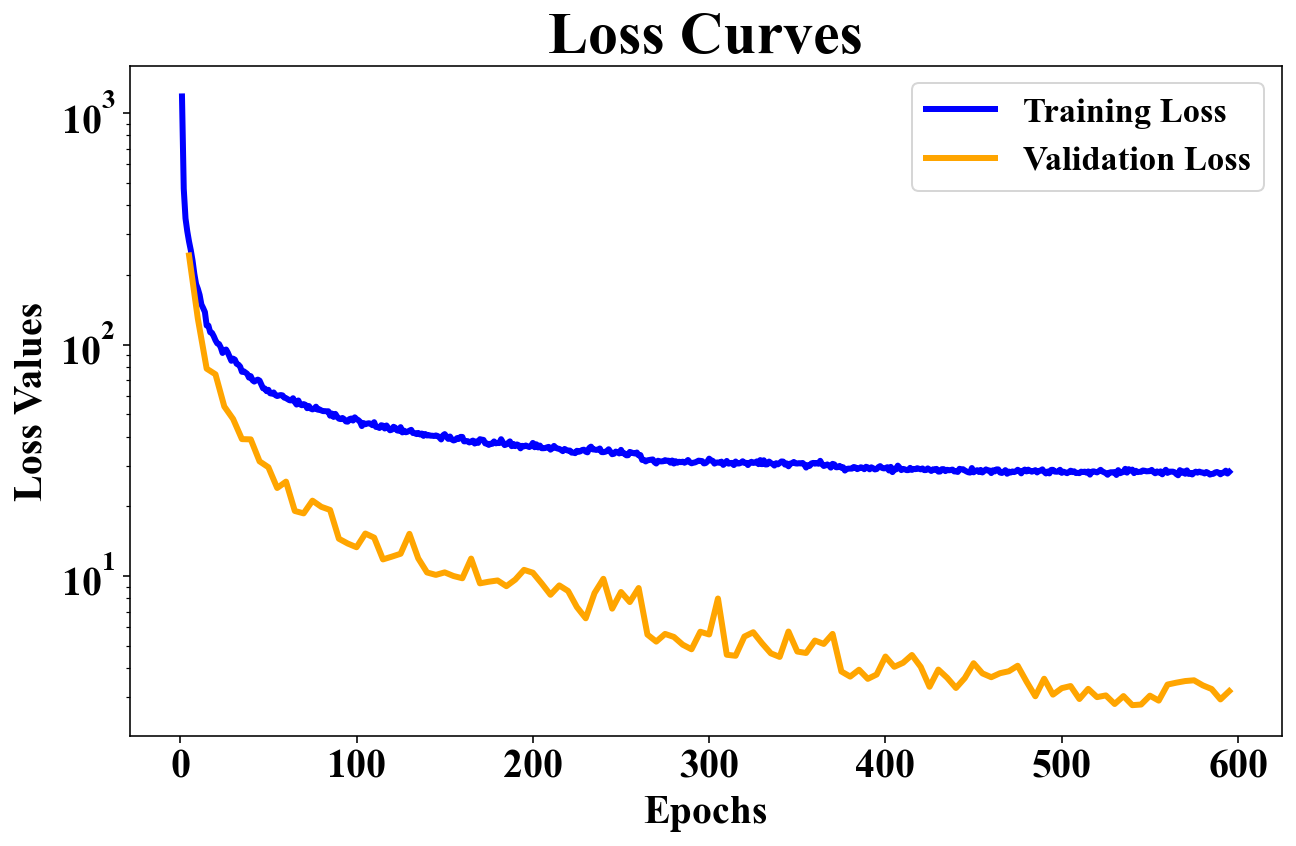

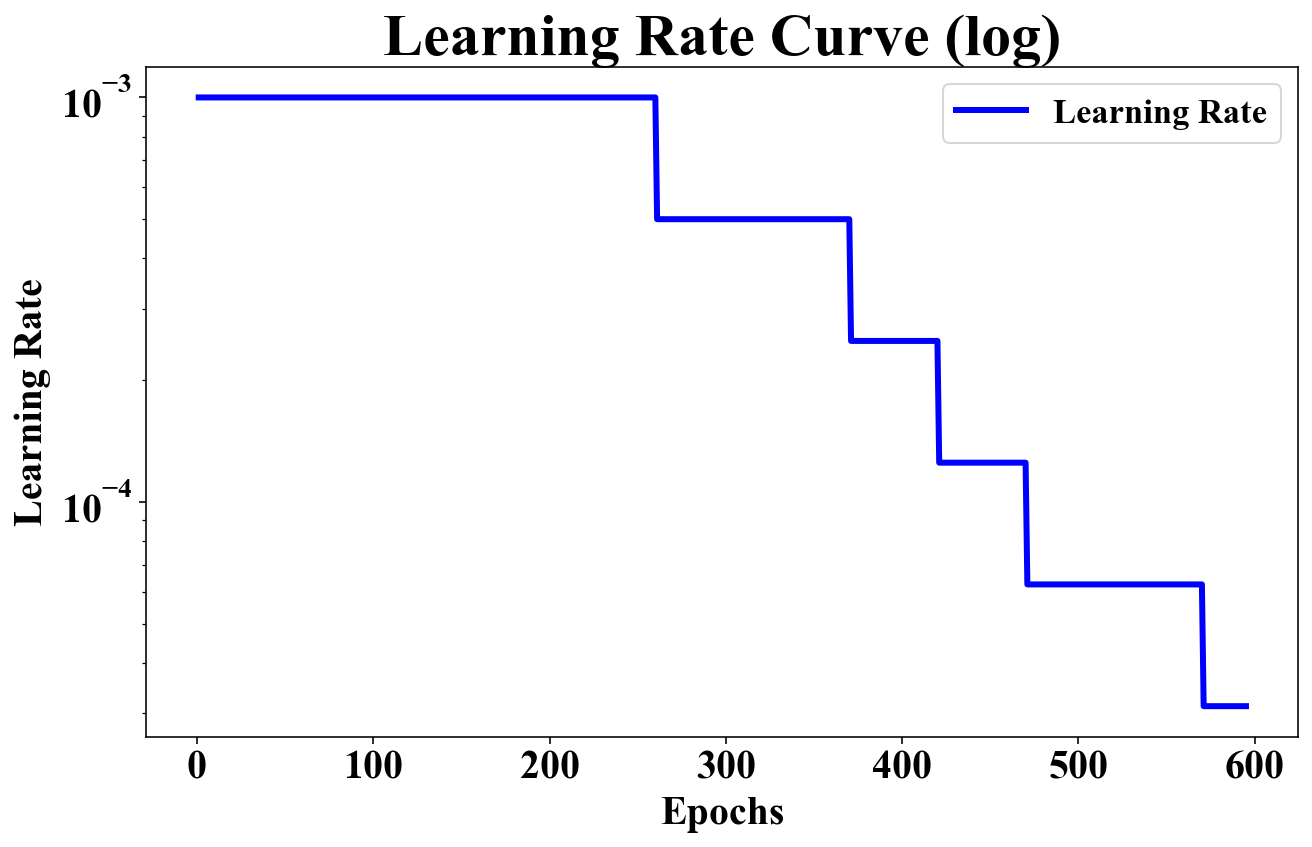

In [18]:
# Plot training curves

# Plot training curves
Loss_Fig = plt.figure(figsize=(10,6))
plt.subplots_adjust(top=0.9, bottom=0.125, left=0.15, right=0.95, 
                        wspace=0.3, hspace=0.5)
Loss_Plot = plt.subplot(111)
if total_epochs < CONFIG["max_epochs"]:
    Loss_Plot.semilogy(np.linspace(1, total_epochs+1, total_epochs+1), MSE_loss, 
                       c='blue', linewidth=3, label='Training Loss')
else:
    Loss_Plot.semilogy(np.linspace(1, total_epochs, total_epochs), MSE_loss, 
                       c='blue', linewidth=3, label='Training Loss')
Loss_Plot.semilogy(val_epochs, val_loss, 
                   c='orange', linewidth=3, label='Validation Loss')
plt.title('Loss Curves', 
          fontweight='bold')
Loss_Plot.set_xlabel('Epochs', 
                     fontweight='bold')
Loss_Plot.set_ylabel(r'Loss Values', # ($log_{10}$)', 
                     fontweight='bold')
Loss_Plot.tick_params(axis='x')
Loss_Plot.tick_params(axis='y')
plt.legend(fontsize='xx-large')
plt.show()

# Plot learning rates
LR_Fig = plt.figure(figsize=(10,6))
plt.subplots_adjust(top=0.9, bottom=0.125, left=0.15, right=0.95, 
                        wspace=0.3, hspace=0.5)
LR_Plot = plt.subplot(111)
if total_epochs < CONFIG["max_epochs"]:
    LR_Plot.semilogy(np.linspace(1, total_epochs+1, total_epochs+1), lr_history, 
                       c='blue', linewidth=3, label='Learning Rate')
else:
    LR_Plot.semilogy(np.linspace(1, total_epochs, total_epochs), lr_history, 
                       c='blue', linewidth=3, label='Learning Rate')
plt.title('Learning Rate Curve (log)', 
          fontweight='bold')
LR_Plot.set_xlabel('Epochs', 
                     fontweight='bold')
LR_Plot.set_ylabel(r'Learning Rate', 
                     fontweight='bold')
LR_Plot.tick_params(axis='x')
LR_Plot.tick_params(axis='y')
plt.legend(fontsize='xx-large')
plt.show()


In [18]:
state_dict = torch.load( "Crystal Lake_generated/EM 3D Surrogate_CNN_20260206.pth", weights_only=True)
model.load_state_dict(state_dict)

# Test trained network on test set
torch.mps.empty_cache()

test_loss = 0
model.eval()
with torch.inference_mode():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)    # Send inputs and label to gpu or cpu
        outputs = model(inputs, x_coords_norm=x_coords)   # Forward pass to get prediction
        
        # Calculate loss for testing
        test_loss += criterion(outputs, targets)
    test_loss /= len(test_loader)

# Print test loss

print(f"Test loss is {test_loss:.4f}")

test_outputs = outputs.detach().cpu().numpy().reshape((outputs.shape[0], N_times*N_obs))
test_targets = targets.detach().cpu().numpy().reshape((targets.shape[0], N_times*N_obs))

print(f"\nTest targets mean/Std: {test_targets.mean():.4f}, {np.std(test_targets):.4f}")
print(f"Test outputs mean/Std: {test_outputs.mean():.4f}, {np.std(test_outputs):.4f}\n")
print(f"Test targets min/max: {test_targets.min():.4f}, {test_targets.max():.4f}")
print(f"Test outputs min/max: {test_outputs.min():.4f}, {test_outputs.max():.4f}")


Test loss is 2.3526

Test targets mean/Std: 97.4038, 188.9819
Test outputs mean/Std: 96.1277, 187.9950

Test targets min/max: -881.0886, 2298.0718
Test outputs min/max: -857.9980, 2328.2844


In [19]:
# Calculate MSE between reconstructed data sets from true PCs and perdicted PCs
MSE_d_pred = np.mean(np.square(test_targets - test_outputs), axis=1)

# Calculate Normalized MSE, so the value of NMSE matches the quality of fitting, excluding the effect of dynamic range
var_true = np.var(test_targets, axis=1)
NMSE = MSE_d_pred / var_true

# Print statistics of the normalized MSE
print(f"Min normalized MSE is {NMSE.min():.4f}")
print(f"Max normalized MSE is {NMSE.max():.4f}")
print(f"Mean normalized MSE is {NMSE.mean():.4f}")
print(f"Std of normalized MSE is {NMSE.std():.4f}")


Min normalized MSE is 0.0005
Max normalized MSE is 0.0825
Mean normalized MSE is 0.0083
Std of normalized MSE is 0.0130


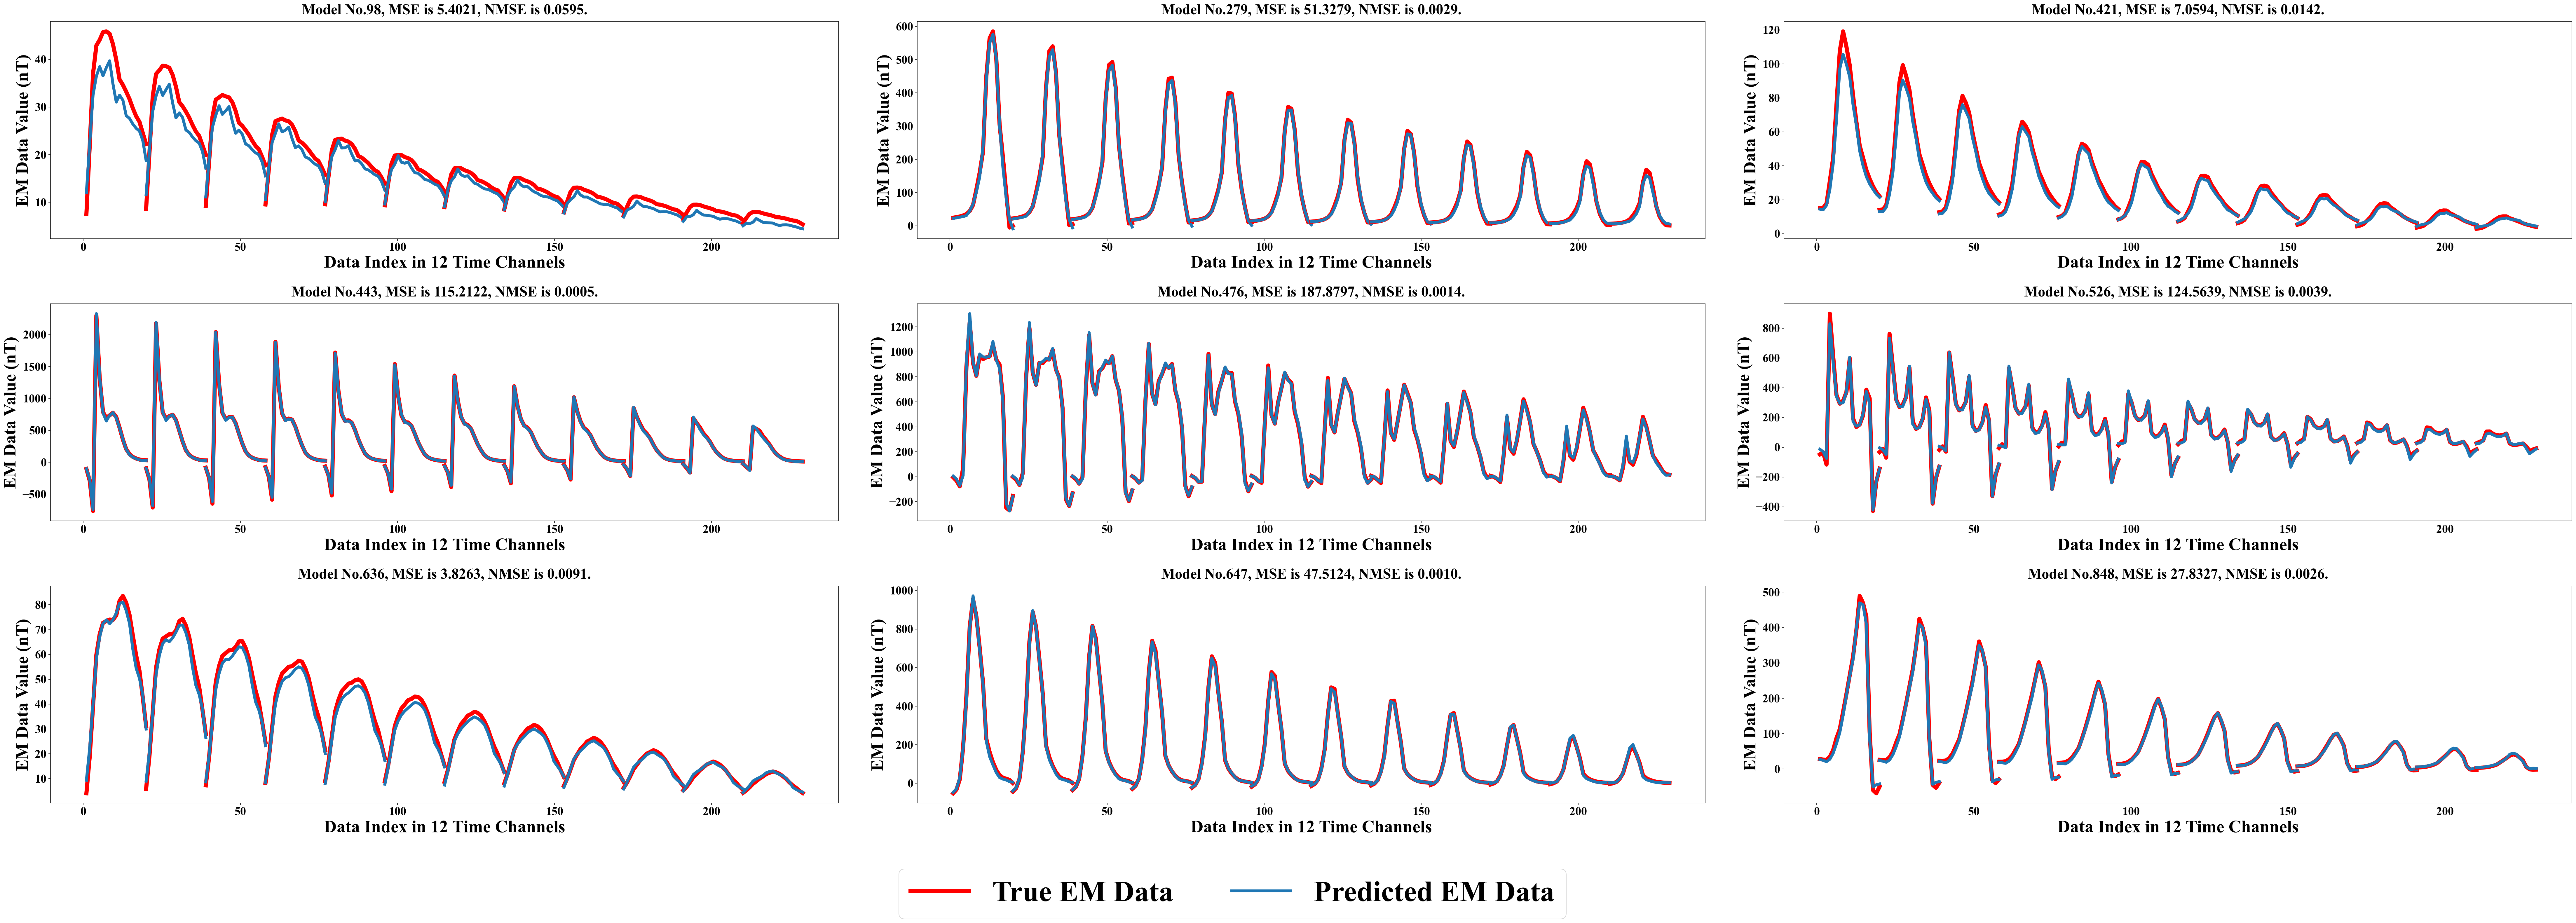

'\n# Plot correspoding conductivity models\nModel_figure = plt.figure(figsize=(15 * root, 12 * root))\nplt.subplots_adjust(\n    top=0.9, bottom=0.125, left=0.15, right=0.95,\n    wspace=0.2, hspace=0.35\n)\nfor i in range(n_reconstruct_plot):\n    Model_Plot = plt.subplot(root, root, i+1)\n    ModelPlot = Model_Plot.imshow(\n        EMsigma_core_raw[test_indices[index_reconstruct_plot[i]], :].reshape((50, 50), order=\'F\').T,\n        extent=[0, 2000, 0, -2000])\n    plt.title(\n        f"Model No.{test_indices[index_reconstruct_plot[i]] + 1}, "\n        f"Major axis {hyper_param[test_indices[index_reconstruct_plot[i]], 0]:.3f}, "\n        f"Aspect ratio {hyper_param[test_indices[index_reconstruct_plot[i]], 1]:.3f}, \n"\n        f"Theta {hyper_param[test_indices[index_reconstruct_plot[i]], 2]:.3f}, "\n        f"Mean {hyper_param[test_indices[index_reconstruct_plot[i]], 3]:.3f}, "\n        f"Sigma {hyper_param[test_indices[index_reconstruct_plot[i]], 4]:.3f}.",\n        fontsize = 25, 

In [22]:
# Plot comparison
n_reconstruct_plot = 9
index_reconstruct_plot = random.sample(range(0, N_test), n_reconstruct_plot)
index_reconstruct_plot = np.sort(index_reconstruct_plot)

root = int(np.ceil(np.sqrt(n_reconstruct_plot))) 
ReCon_Figure = plt.figure(figsize=(25 * root, 8 * root))
plt.subplots_adjust(
    top=0.9, bottom=0.125, left=0.15, right=0.95,
    wspace=0.1, hspace=0.3
)
for i in range(n_reconstruct_plot):
    ReCon_Plot = plt.subplot(root, root, i+1)
    for j in range(N_times):
        ReCon_Plot.plot(
            Rx_loc[:, 0] if N_times == 1 else np.linspace(j * Rx_loc[:, 0].shape[0] + 1, (j + 1) * Rx_loc[:, 0].shape[0] + 1, Rx_loc[:, 0].shape[0]),
            test_targets[index_reconstruct_plot[i], j * Rx_loc[:, 0].shape[0]: (j + 1) * Rx_loc[:, 0].shape[0]], 
            color='red', linewidth=7, label='True EM Data' if j == 0 else None
        )
        ReCon_Plot.plot(
            Rx_loc[:, 0] if N_times == 1 else np.linspace(j * Rx_loc[:, 0].shape[0] + 1, (j + 1) * Rx_loc[:, 0].shape[0] + 1, Rx_loc[:, 0].shape[0]),
            test_outputs[index_reconstruct_plot[i], j * Rx_loc[:, 0].shape[0]: (j + 1) * Rx_loc[:, 0].shape[0]], 
            color='#1f77b4', linewidth=5, label='Predicted EM Data' if j == 0 else None
        )
    plt.title(
        f"Model No.{test_indices[index_reconstruct_plot[i]] + 1}, "
        f"MSE is {MSE_d_pred[index_reconstruct_plot[i]]:.4f}, "
        f"NMSE is {NMSE[index_reconstruct_plot[i]]:.4f}.",
        fontsize = 25, fontweight='bold',
        pad=13
    )
    ReCon_Plot.set_xlabel(f'X (m)' if N_times == 1 else f'Data Index in {N_times} Time Channels', fontsize=30, fontweight='bold')
    ReCon_Plot.set_ylabel('EM Data Value (nT)', fontsize=30, fontweight='bold')
plt.legend(
    loc="lower center", ncol=3, fontsize=50,
    bbox_to_anchor=(-0.7, -0.6))
plt.show()

"""
# Plot correspoding conductivity models
Model_figure = plt.figure(figsize=(15 * root, 12 * root))
plt.subplots_adjust(
    top=0.9, bottom=0.125, left=0.15, right=0.95,
    wspace=0.2, hspace=0.35
)
for i in range(n_reconstruct_plot):
    Model_Plot = plt.subplot(root, root, i+1)
    ModelPlot = Model_Plot.imshow(
        EMsigma_core_raw[test_indices[index_reconstruct_plot[i]], :].reshape((50, 50), order='F').T,
        extent=[0, 2000, 0, -2000])
    plt.title(
        f"Model No.{test_indices[index_reconstruct_plot[i]] + 1}, "
        f"Major axis {hyper_param[test_indices[index_reconstruct_plot[i]], 0]:.3f}, "
        f"Aspect ratio {hyper_param[test_indices[index_reconstruct_plot[i]], 1]:.3f}, \n"
        f"Theta {hyper_param[test_indices[index_reconstruct_plot[i]], 2]:.3f}, "
        f"Mean {hyper_param[test_indices[index_reconstruct_plot[i]], 3]:.3f}, "
        f"Sigma {hyper_param[test_indices[index_reconstruct_plot[i]], 4]:.3f}.",
        fontsize = 25, fontweight='bold',
        pad=13
    )
    plt.gca().invert_yaxis()
    Model_Plot.set_xlabel('X (m)', fontsize=30, fontweight='bold')
    Model_Plot.set_ylabel('Z (m)', fontsize=30, fontweight='bold')
    cbar = plt.colorbar(ModelPlot)
    cbar.set_label(
        label='Log Conductivity ($ln$ S/m)',
        fontweight='bold', fontsize=30,
        labelpad=40, rotation=-90
    )
plt.show()
"""



In [ ]:
# Save NN parameters
torch.save(model.state_dict(), "EM 3D Surrogate.pth")